In [6]:
from order_book import OrderBook
from models import Order, ReqType, Request, Trade
from agents import Agent
from simulation import Simulation
from strategies.naivemm import NaiveMM
from strategies.random_strat import Random
from strategies.inventorymm import InventoryMM

from analytics import Analytics

from collections import deque
from dataclasses import dataclass
from enum import Enum
import matplotlib as plt

In [7]:
sim = Simulation(initial_price=100)
analysis = Analytics(sim)

# create 100 random agents with fixed probabilities
for i in range(1, 11):
    strat = Random(
        buy_probability=0.33,
        sell_probability=0.33,
        cancel_probability=0.2,
        limit_probability=0.8,
        max_quantity=10,
        max_price_offset=10,
        reference_price=sim.initial_price,
    )
    agent = Agent(
        agent_id=i,
        initial_cash=10000,
        initial_position=100,
        strategy=strat
    )
    sim.agents[i] = agent

strat1 = NaiveMM(
    half_spread=2,
    time_req=2,
    tolerance=2,
    quantity=10
)

sim.agents[11] = Agent(
    agent_id=11,
    initial_cash=10000,
    initial_position=100,
    strategy=strat1,
)

strat2 = InventoryMM(
    half_spread=2,
    time_req=2,
    tolerance=2,
    quantity=10,
    target_ratio=0.5,
    ratio_error=0.1
)

sim.agents[12] = Agent(
    agent_id=12,
    initial_cash=10000,
    initial_position=100,
    strategy=strat2,
)

In [8]:
sim.run_sim(100000)
len(sim.book.trades)

52425

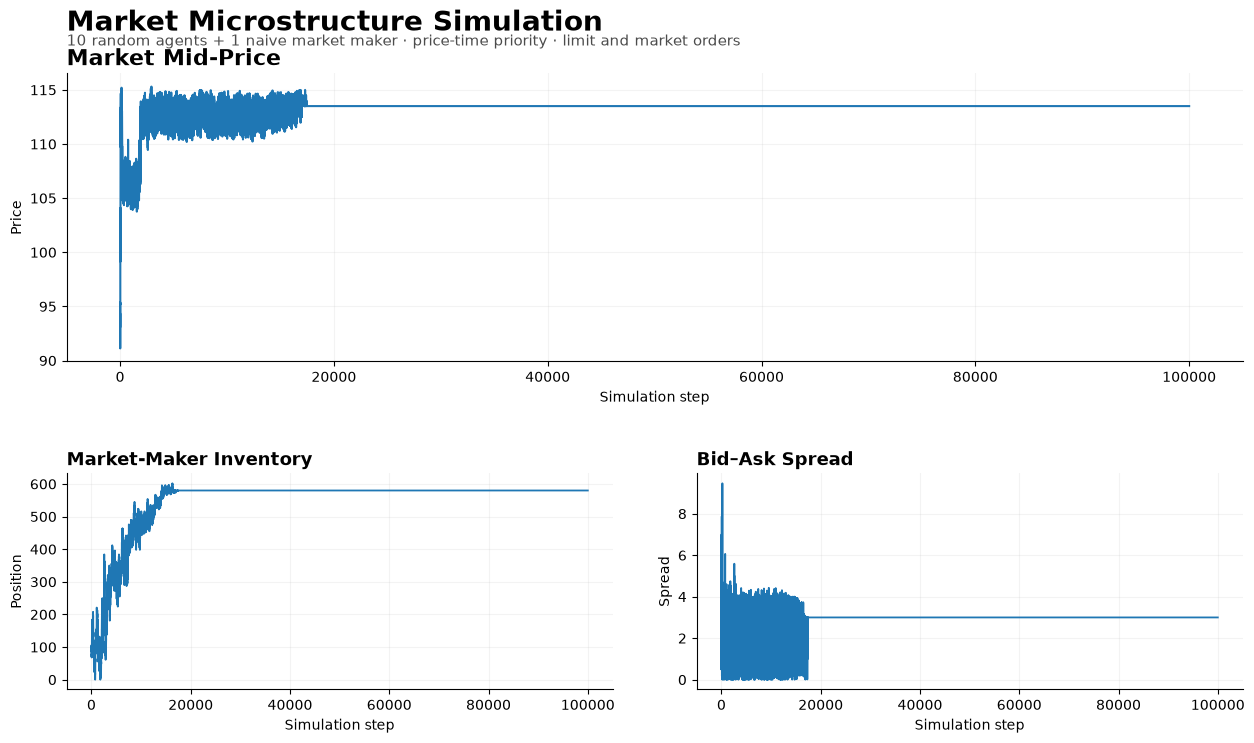

In [9]:

analysis.plot_portfolio_summary(
    sim,
    market_maker_id=11,
)

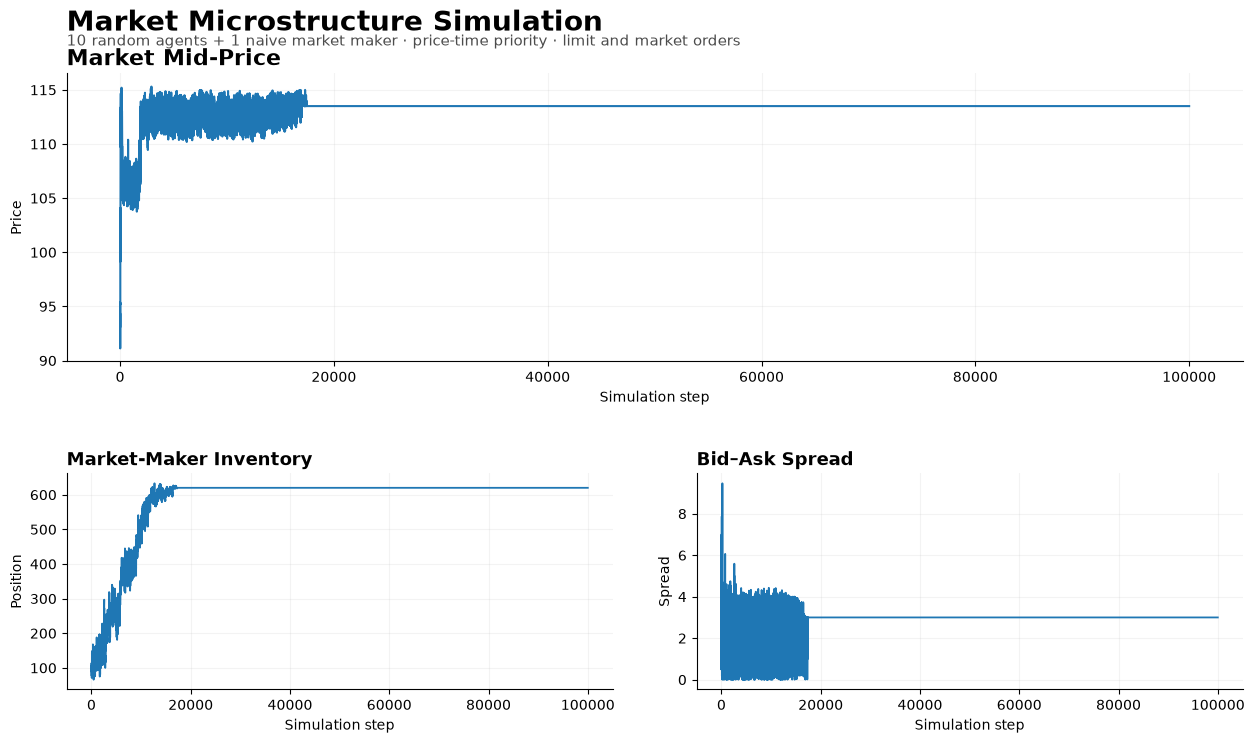

In [10]:

analysis.plot_portfolio_summary(
    sim,
    market_maker_id=12,
)